Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

===== DATA OVERVIEW =====
   Project_ID  Department  Investment_Cost  Expected_Cashflow_Year1  \
0           1  Operations           184654                   583556   
1           2   Marketing          2054354                  1447527   
2           3     Finance          2516182                  1372905   
3           4  Operations          3574675                  1817640   
4           5  Operations          2752991                   792139   

   Expected_Cashflow_Year2  Expected_Cashflow_Year3  Historical_ROI  \
0                  2348816                  1888756            0.08   
1                   541234                   278576            0.15   
2                  1998260                  2312990            0.19   
3                   189182                  1434250            0.22   
4                  1571101                   111087           

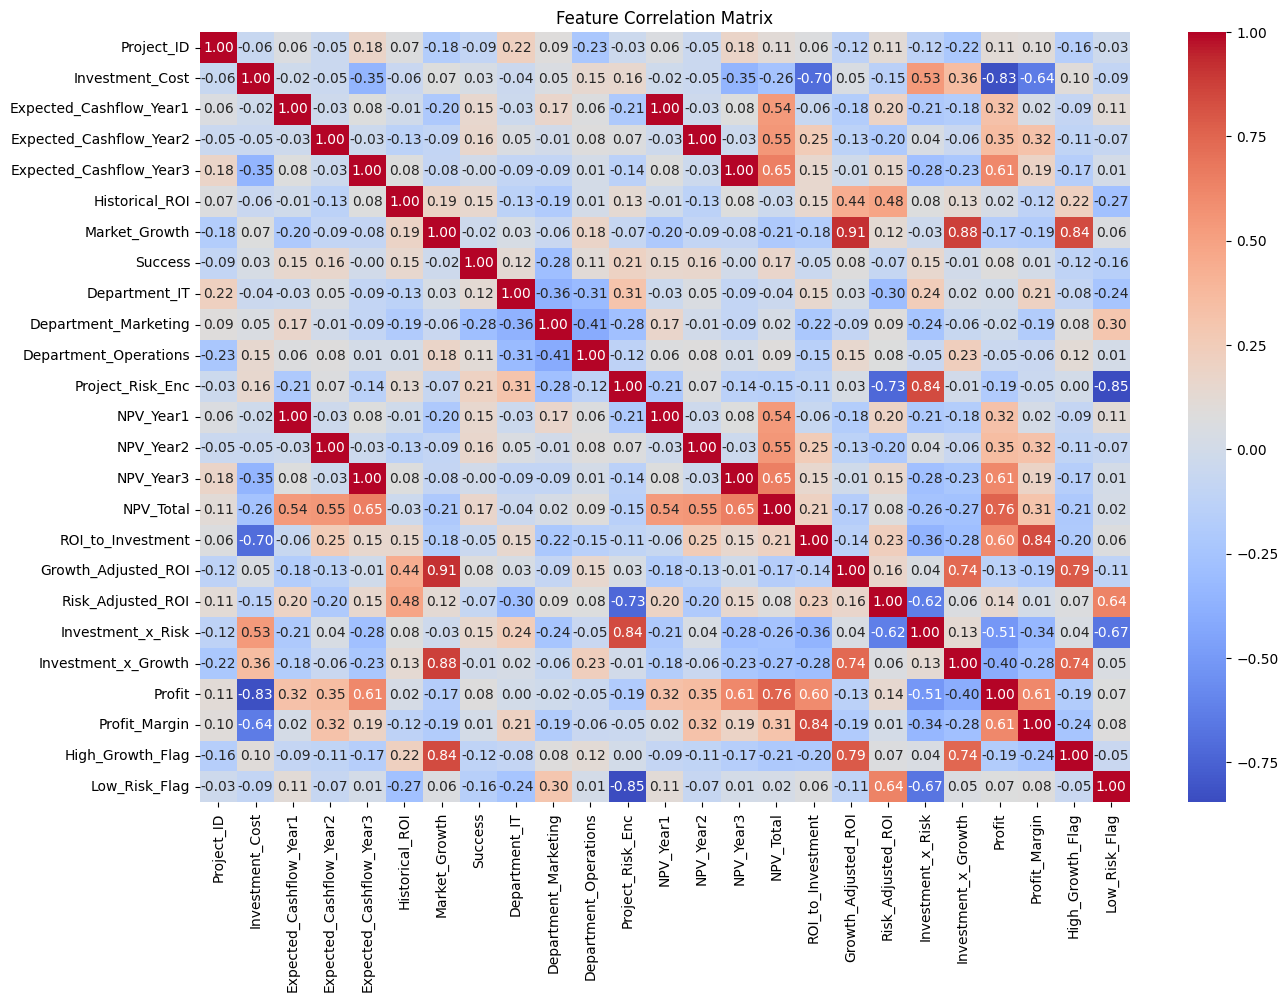


--- RandomForest Regression ---
MAE: 570845.3476371153
R2: 0.6724716154690724

--- XGBoost Regression ---
MAE: 595328.619515402
R2: 0.6431152201681429

--- RandomForest ---
Accuracy: 0.5
ROC AUC: 0.48
Log Loss: 0.7350076966077964

--- Logistic ---
Accuracy: 0.4
ROC AUC: 0.32000000000000006
Log Loss: 1.0908919063756217

--- XGBoost ---
Accuracy: 0.6
ROC AUC: 0.68
Log Loss: 0.66263627123143

===== TOP 5 PROJECTS =====
    Project_ID  Investment_Cost  Expected_Cashflow_Year1  \
44          45          1411736                  1700237   
38          39          1146797                  1046107   
42          43           664685                   963910   
34          35           296769                  1806187   
12          13          3485357                  1475472   

    Expected_Cashflow_Year2  Expected_Cashflow_Year3  Historical_ROI  \
44                  1677880                  1711909            0.11   
38                   125766                  2958926            0.18   
42

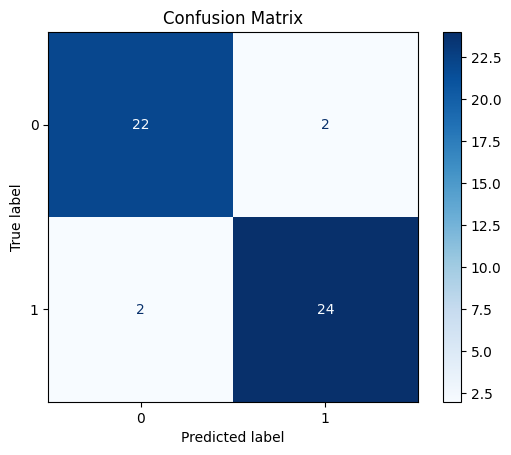

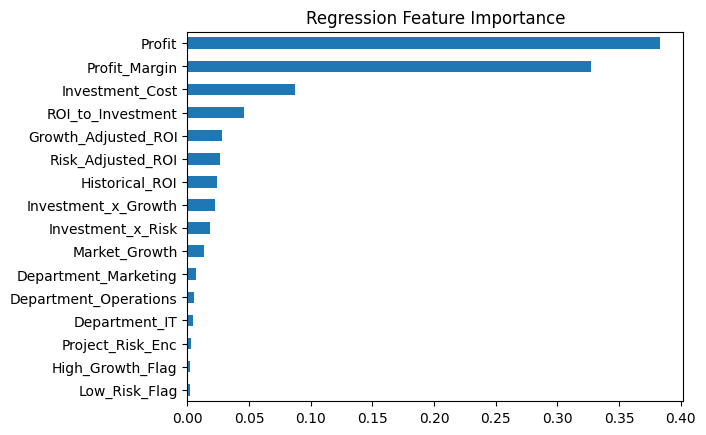

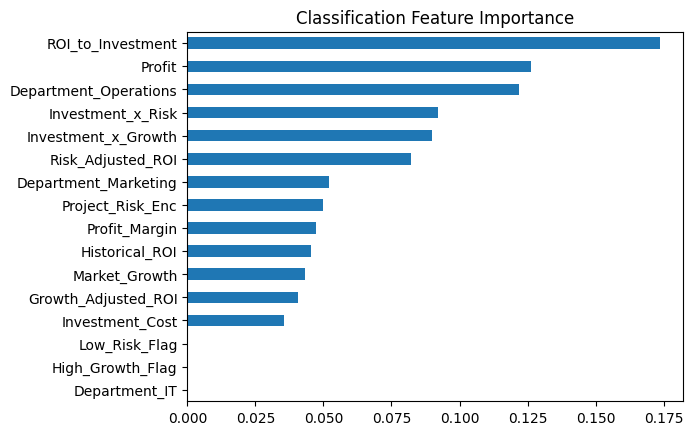


Generating SHAP plots...


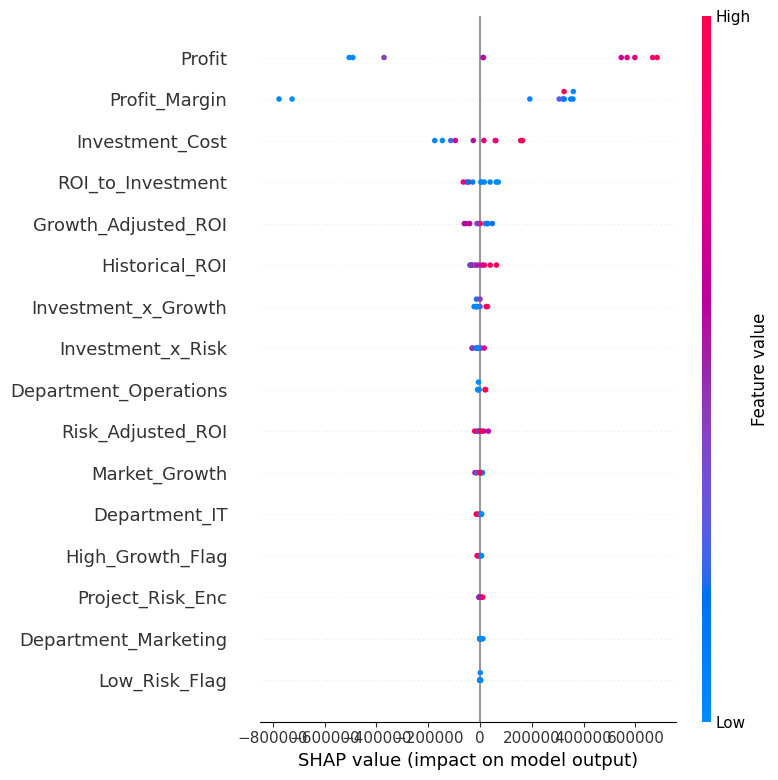

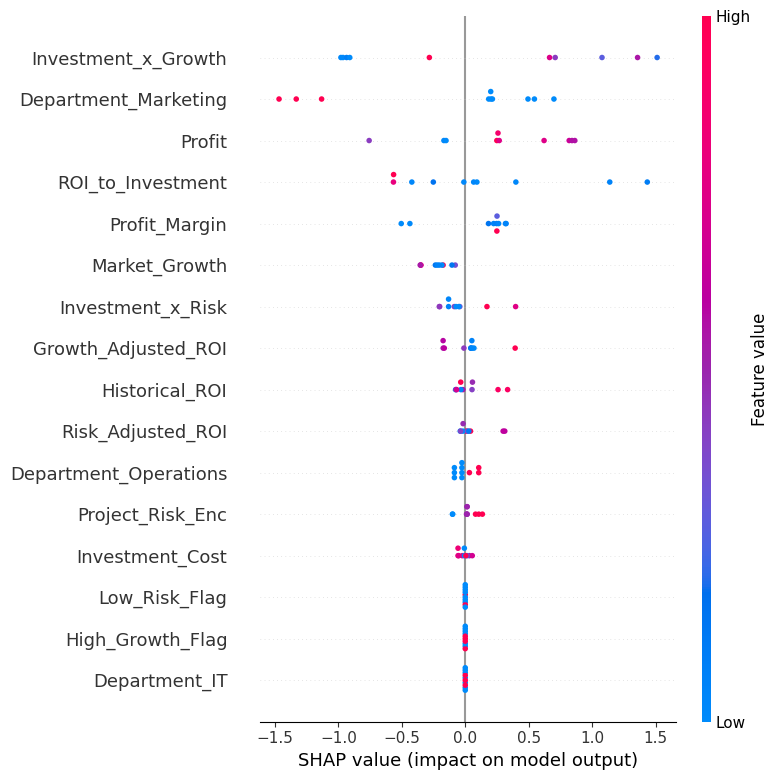

In [11]:
# =========================================
# 1. IMPORT LIBRARIES
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import seaborn as sns

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, r2_score,
    accuracy_score, roc_auc_score, log_loss,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBRegressor, XGBClassifier


# =========================================
# 2. LOAD DATA
# =========================================
drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/Colab Notebooks/ml-for-finance-project/corporate_projects.csv'
df = pd.read_csv(file_path)

df_mod = df.copy()

print("\n===== DATA OVERVIEW =====")
print(df_mod.head())
print("\nClass Distribution:\n", df_mod['Success'].value_counts(normalize=True))
print("\nSummary Stats:\n", df_mod.describe())


# =========================================
# 3. PREPROCESSING
# =========================================

# Encode categorical
df_mod = pd.get_dummies(df_mod, columns=['Department'], drop_first=True)

# Risk encoding
risk_map = {'Low': 0, 'Medium': 1, 'High': 2}
df_mod['Project_Risk_Enc'] = df_mod['Project_Risk'].map(risk_map)
df_mod = df_mod.drop(columns=['Project_Risk']) # Drop original string column after encoding


# =========================================
# 4. FEATURE ENGINEERING
# =========================================

discount_rate = 0.1

# NPV Calculation
for i in range(1, 4):
    df_mod[f'NPV_Year{i}'] = df_mod[f'Expected_Cashflow_Year{i}'] / ((1 + discount_rate) ** i)

df_mod['NPV_Total'] = df_mod[['NPV_Year1', 'NPV_Year2', 'NPV_Year3']].sum(axis=1)

# Financial Ratios
df_mod['ROI_to_Investment'] = df_mod['Historical_ROI'] / (df_mod['Investment_Cost'] + 1)
df_mod['Growth_Adjusted_ROI'] = df_mod['Historical_ROI'] * df_mod['Market_Growth']
df_mod['Risk_Adjusted_ROI'] = df_mod['Historical_ROI'] / (1 + df_mod['Project_Risk_Enc'])

# Interaction Features
df_mod['Investment_x_Risk'] = df_mod['Investment_Cost'] * df_mod['Project_Risk_Enc']
df_mod['Investment_x_Growth'] = df_mod['Investment_Cost'] * df_mod['Market_Growth']

# Profit Metrics
df_mod['Profit'] = df_mod['NPV_Total'] - df_mod['Investment_Cost']
df_mod['Profit_Margin'] = df_mod['Profit'] / (df_mod['Investment_Cost'] + 1)

# Flags
df_mod['High_Growth_Flag'] = (df_mod['Market_Growth'] > df_mod['Market_Growth'].median()).astype(int)
df_mod['Low_Risk_Flag'] = (df_mod['Project_Risk_Enc'] == 0).astype(int)

# =========================================
# 5. CORRELATION MATRIX
# =========================================
plt.figure(figsize=(15, 10))
sns.heatmap(df_mod.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()


# =========================================
# 6. FEATURE / TARGET SPLIT
# =========================================

drop_cols = [
    'Project_ID', 'NPV_Total', 'Success',
    'Expected_Cashflow_Year1', 'Expected_Cashflow_Year2', 'Expected_Cashflow_Year3',
    'NPV_Year1', 'NPV_Year2', 'NPV_Year3'
]

X = df_mod.drop(columns=drop_cols)
y_reg = df_mod['NPV_Total']
y_clf = df_mod['Success']


# =========================================
# 7. TRAIN-TEST SPLIT
# =========================================
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X, y_reg, y_clf, test_size=0.2, random_state=42
)


# =========================================
# 8. SCALING (FOR LOGISTIC)
# =========================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# =========================================
# 9. MODEL TRAINING
# =========================================

# Regression Models
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
xgb_reg = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42)

rf_reg.fit(X_train, y_reg_train)
xgb_reg.fit(X_train, y_reg_train)

# Classification Models
rf_clf = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42)
lr_clf = LogisticRegression(random_state=42)
xgb_clf = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42)

rf_clf.fit(X_train, y_clf_train)
lr_clf.fit(X_train_scaled, y_clf_train)
xgb_clf.fit(X_train, y_clf_train)


# =========================================
# 10. EVALUATION
# =========================================

def evaluate_regression(name, y_true, y_pred):
    print(f"\n--- {name} ---")
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("R2:", r2_score(y_true, y_pred))


def evaluate_classification(name, y_true, y_pred, y_prob):
    print(f"\n--- {name} ---")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("ROC AUC:", roc_auc_score(y_true, y_prob))
    print("Log Loss:", log_loss(y_true, y_prob))


# Regression Results
evaluate_regression("RandomForest Regression", y_reg_test, rf_reg.predict(X_test))
evaluate_regression("XGBoost Regression", y_reg_test, xgb_reg.predict(X_test))

# Classification Results
evaluate_classification("RandomForest", y_clf_test,
                        rf_clf.predict(X_test),
                        rf_clf.predict_proba(X_test)[:,1])

evaluate_classification("Logistic", y_clf_test,
                        lr_clf.predict(X_test_scaled),
                        lr_clf.predict_proba(X_test_scaled)[:,1])

evaluate_classification("XGBoost", y_clf_test,
                        xgb_clf.predict(X_test),
                        xgb_clf.predict_proba(X_test)[:,1])


# =========================================
# 11. FINAL MODEL SELECTION
# =========================================
final_reg_model = rf_reg
final_clf_model = xgb_clf


# =========================================
# 12. PREDICTIONS & BUSINESS METRICS
# =========================================
df_mod['Predicted_Cashflow'] = final_reg_model.predict(X)
df_mod['Predicted_Success_Prob'] = final_clf_model.predict_proba(X)[:,1]

# Expected Value
df_mod['Predicted_EV'] = df_mod['Predicted_Success_Prob'] * (
    df_mod['Predicted_Cashflow'] - df_mod['Investment_Cost']
)

# Risk-adjusted return
df_mod['Risk_Adjusted_Return'] = df_mod['Predicted_EV'] / (1 + df_mod['Project_Risk_Enc'])

# Ranking
df_ranked = df_mod.sort_values(by='Risk_Adjusted_Return', ascending=False)

print("\n===== TOP 5 PROJECTS =====")
print(df_ranked.head(5))


# =========================================
# 13. CONFUSION MATRIX
# =========================================
cm = confusion_matrix(y_clf, final_clf_model.predict(X))
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


# =========================================
# 14. FEATURE IMPORTANCE
# =========================================
def plot_importance(model, title):
    importance = pd.Series(model.feature_importances_, index=X.columns).sort_values()
    importance.plot(kind='barh')
    plt.title(title)
    plt.show()

plot_importance(final_reg_model, "Regression Feature Importance")
plot_importance(final_clf_model, "Classification Feature Importance")


# =========================================
# 15. SHAP EXPLAINABILITY
# =========================================
X_train_shap = X_train.astype(float)
X_test_shap = X_test.astype(float)

print("\nGenerating SHAP plots...")

explainer = shap.TreeExplainer(final_reg_model)
shap_values = explainer.shap_values(X_test_shap, check_additivity=False)
shap.summary_plot(shap_values, X_test_shap)

explainer = shap.TreeExplainer(final_clf_model)
shap_values = explainer.shap_values(X_test_shap, check_additivity=False)
shap.summary_plot(shap_values, X_test_shap)